# Q-Learning — project documentation

## What is Q-Learning and how does it work here

Q-Learning is a reinforcement learning algorithm where the agent learns by trial and error — it takes actions, gets rewards (or penalties), and slowly figures out which actions are worth taking in which states. The core idea is a Q-table, a 2D array of shape `(n_states, n_actions)`, where each cell holds an estimate of how good it is to take a given action in a given state.

After every step the agent updates the relevant cell using:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[\text{target} - Q(s, a)\right]
$$

The `target` is what we think the value *should* be, and it's computed differently depending on what happened:
- **terminated** — the episode ended for real (e.g. passenger delivered), so `target = r`. There's no next state, so we don't try to bootstrap from one.
- **truncated or regular step** — `target = r + γ · max_a' Q(s', a')`, we use the best known value of the next state to estimate the future.

Getting this distinction wrong is a common bug — if you treat a terminal state like a regular one, you add a discounted future reward that doesn't actually exist, which slowly corrupts the whole table.

For exploration the agent uses **ε-greedy**: most of the time it picks the best known action, but with probability ε it picks randomly. Epsilon starts high (lots of exploration) and decays after each episode, so over time the agent stops exploring and starts exploiting what it learned.

---

## Classes

### `TrainingConfig`
Just a dataclass with all the hyperparameters in one place: `alpha`, `gamma`, `epsilon_start`, `epsilon_end`, `epsilon_decay`, `n_episodes`, `max_steps`. Passing this around instead of a bunch of loose floats keeps things clean.

### `QLearningAgent`
The actual algorithm lives here. Holds the `q_table` and implements:

- `select_action(state, explore)` — ε-greedy action selection; with `explore=False` it's pure greedy (used when evaluating)
- `update(...)` — the Q-update rule with the terminated/truncated logic described above
- `decay_epsilon()` — multiplies epsilon by the decay factor after each episode

### `ExperimentRunner`
Wraps the agent and the gym environment together. Handles the step loop so you don't have to write it everywhere.

- `run_episode(training)` — runs one episode; if `training=True` it calls `update()` and `decay_epsilon()` along the way
- `train()` — loops over all episodes, returns a `TrainingResult` with stats and a copy of the final Q-table
- `run_random(n_episodes)` — same thing but with random actions, no learning; used as a baseline

### `Evaluator`
Computes statistics and draws plots. Nothing fancy, just numpy for the numbers and matplotlib for the charts.

- `stability_analysis(results)` — takes results from multiple training runs and computes mean/std/min/max across them
- `plot_learning_curve` — reward over episodes with a rolling mean to smooth out the noise
- `plot_comparison` — boxplot comparing Q-Learning vs random agent
- `plot_stability` — shows how consistent training is across runs (mean ± std band)

### `Experiment`
The top-level class that ties everything together. You give it an `env_id` string and it handles the rest — trains the agent multiple times, picks the best run, evaluates it, and collects random baseline stats. The notebook only ever touches this class.

### Result dataclasses
`EpisodeStats` — stores what happened in one episode. `TrainingResult` — stores the full training history plus the final Q-table. `BenchmarkResult` — aggregates stats across multiple runs for the stability analysis.


In [1]:
from modules.config import TrainingConfig
from modules.experiment import Experiment, grid_search

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:22<00:00,  8.30s/it]


Stability (10 runs):  mean=-12.34  std=0.30  min=-12.86  max=-11.86
Q-Learning eval:  7.94
Random agent:     -775.95


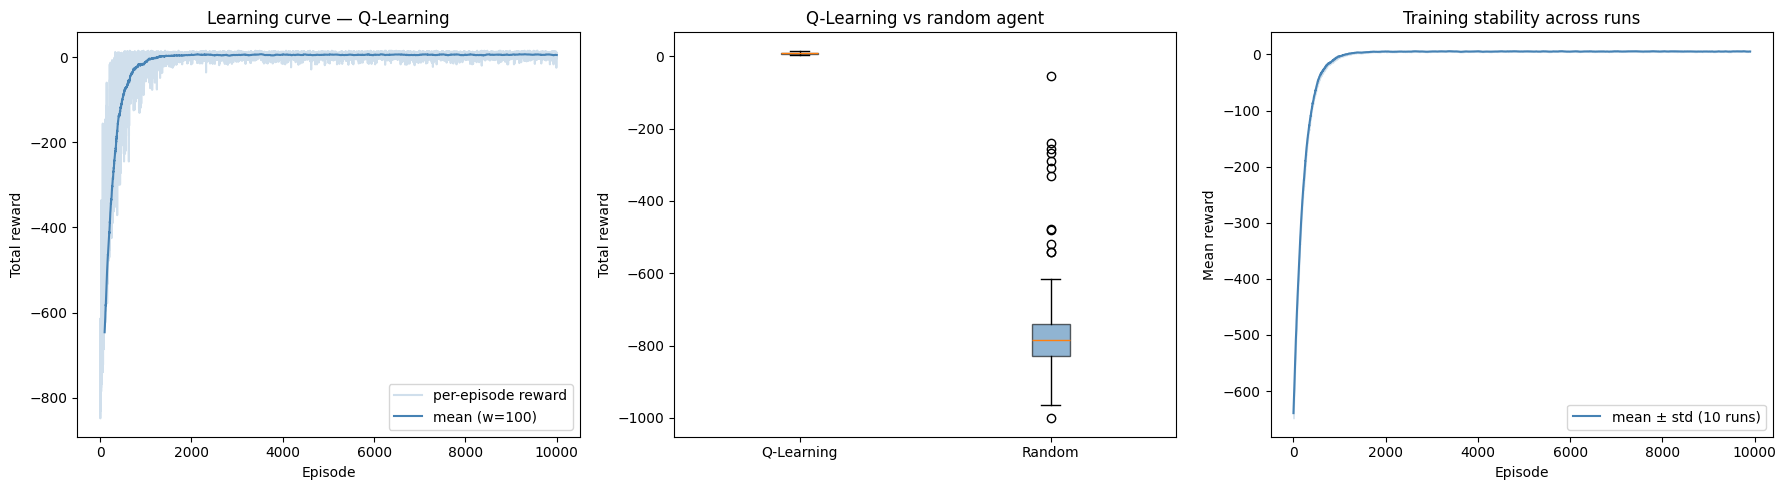

In [2]:
experiment = Experiment("Taxi-v4", config=TrainingConfig(), n_runs=10)
experiment.run(eval_episodes=500)
experiment.print_summary()
experiment.plot_all()

Grid search:   0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:12<00:00, 12.39s/it]


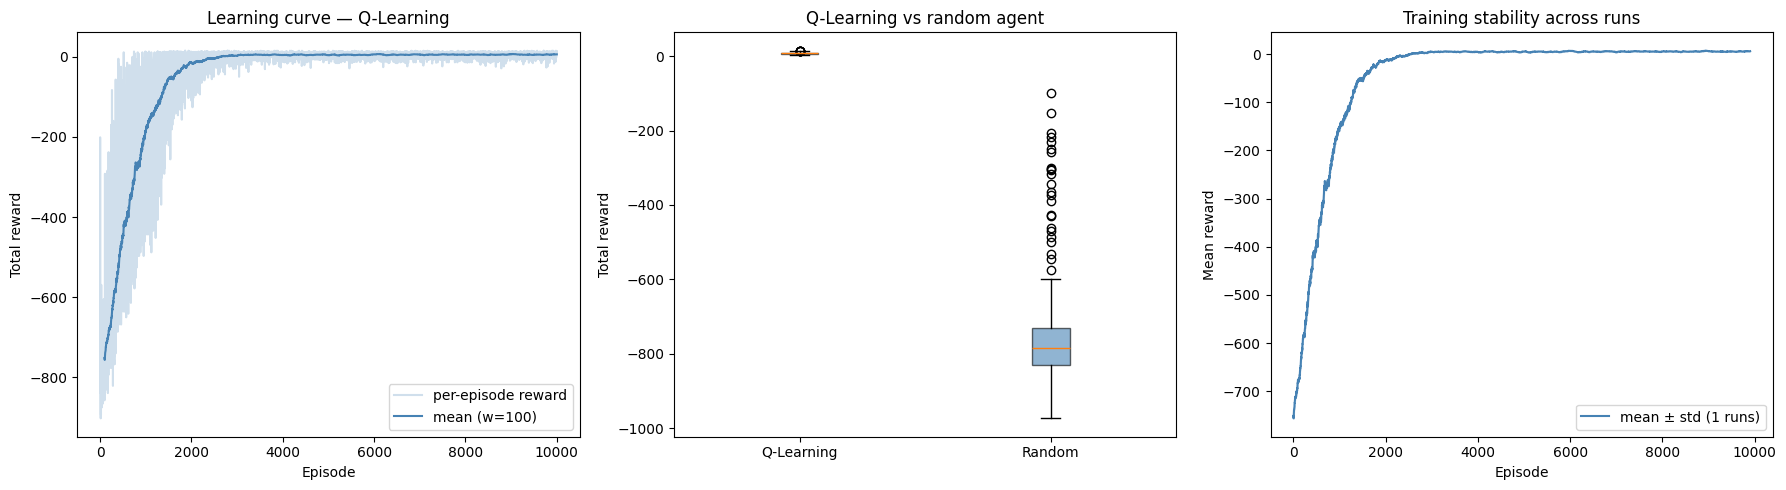

,alpha,gamma,epsilon_decay,eval_mean,eval_std,eval_min,eval_max,train_mean
0,0.10,0.99,0.995,8.18,2.68,3.0,15.0,-12.08
1,0.05,0.99,0.995,8.05,2.60,3.0,15.0,-20.49
2,0.05,0.95,0.999,8.03,2.57,3.0,15.0,-48.72
3,0.05,0.95,0.995,7.93,2.57,3.0,15.0,-21.17
4,0.10,0.99,0.999,7.84,2.54,3.0,15.0,-32.79
5,0.10,0.95,0.999,7.81,2.57,3.0,15.0,-33.46
6,0.05,0.99,0.999,7.80,2.63,3.0,14.0,-46.30
7,0.10,0.95,0.995,7.78,2.56,3.0,15.0,-12.22


In [3]:
results = grid_search(
    env_id="Taxi-v4",
    param_grid={
        "alpha":         [0.05, 0.1],
        "gamma":         [0.95, 0.99],
        "epsilon_decay": [0.999, 0.995],
    },
    save_path="grid_search.csv",
)
results